<a href="https://colab.research.google.com/github/Gunasalini/student-performance-data-science/blob/main/Week_5_Comprehensive_Data_Science_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

['student.zip', '.student.zip_old']
['student-merge.R', 'student-por.csv', 'student-mat.csv', 'student.txt']
student_data/extracted/student-por.csv
student_data/extracted/student-mat.csv


Week 5: Comprehensive Data Science Project and Strategic Recommendations

In [3]:
from google.colab import files
uploaded = files.upload()

Saving student+performance.zip to student+performance.zip


In [4]:
import zipfile
import os

with zipfile.ZipFile("student+performance.zip", "r") as zip_ref:
    zip_ref.extractall("student_data")

print(os.listdir("student_data"))
with zipfile.ZipFile("student_data/student.zip", "r") as zip_ref:
    zip_ref.extractall("student_data/extracted")

print(os.listdir("student_data/extracted"))
for root, dirs, files in os.walk("student_data"):
    for file in files:
        if file.endswith(".csv"):
            print(os.path.join(root, file))

['student.zip', '.student.zip_old']
['student-merge.R', 'student-por.csv', 'student-mat.csv', 'student.txt']
student_data/extracted/student-por.csv
student_data/extracted/student-mat.csv


In [5]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

In [6]:
#Data Acquisition and Loading
# Load the Mathematics and Portuguese datasets

math_df = pd.read_csv("student_data/extracted/student-mat.csv", sep=";")
por_df = pd.read_csv("student_data/extracted/student-por.csv", sep=";")

# Add a column to identify the subject
math_df["subject"] = "Mathematics"
por_df["subject"] = "Portuguese"

# Combine both datasets
combined_df = pd.concat([math_df, por_df], ignore_index=True)

# Display basic information
print("Mathematics dataset shape:", math_df.shape)
print("Portuguese dataset shape:", por_df.shape)
print("Combined dataset shape:", combined_df.shape)

combined_df.head()

Mathematics dataset shape: (395, 34)
Portuguese dataset shape: (649, 34)
Combined dataset shape: (1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,Mathematics
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,Mathematics
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,Mathematics
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,Mathematics
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,Mathematics


In [7]:
#Data Inspection and Cleaning
# Check dataset information
combined_df.info()

# Check total missing values
missing_values = combined_df.isnull().sum().sum()

# Check duplicate rows
duplicate_rows = combined_df.duplicated().sum()

print("\nTotal missing values:", missing_values)
print("Number of duplicate rows:", duplicate_rows)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1044 entries, 0 to 1043
Data columns (total 34 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      1044 non-null   object
 1   sex         1044 non-null   object
 2   age         1044 non-null   int64 
 3   address     1044 non-null   object
 4   famsize     1044 non-null   object
 5   Pstatus     1044 non-null   object
 6   Medu        1044 non-null   int64 
 7   Fedu        1044 non-null   int64 
 8   Mjob        1044 non-null   object
 9   Fjob        1044 non-null   object
 10  reason      1044 non-null   object
 11  guardian    1044 non-null   object
 12  traveltime  1044 non-null   int64 
 13  studytime   1044 non-null   int64 
 14  failures    1044 non-null   int64 
 15  schoolsup   1044 non-null   object
 16  famsup      1044 non-null   object
 17  paid        1044 non-null   object
 18  activities  1044 non-null   object
 19  nursery     1044 non-null   object
 20  higher  

In [8]:
# Create a clean working copy for further analysis
cleaned_df = combined_df.copy()

print("Cleaned dataset shape:", cleaned_df.shape)
print("Total missing values:", cleaned_df.isnull().sum().sum())
print("Duplicate rows:", cleaned_df.duplicated().sum())

Cleaned dataset shape: (1044, 34)
Total missing values: 0
Duplicate rows: 0


In [9]:
#Exploratory Data Analysis
# Summary statistics for numerical variables
cleaned_df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000,1044.000000
mean,16.726054,2.603448,2.387931,1.522989,1.970307,0.264368,3.935824,3.201149,3.156130,1.494253,2.284483,3.543103,4.434866,11.213602,11.246169,11.341954
std,1.239975,1.124907,1.099938,0.731727,0.834353,0.656142,0.933401,1.031507,1.152575,0.911714,1.285105,1.424703,6.210017,2.983394,3.285071,3.864796
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,9.000000,9.000000,10.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


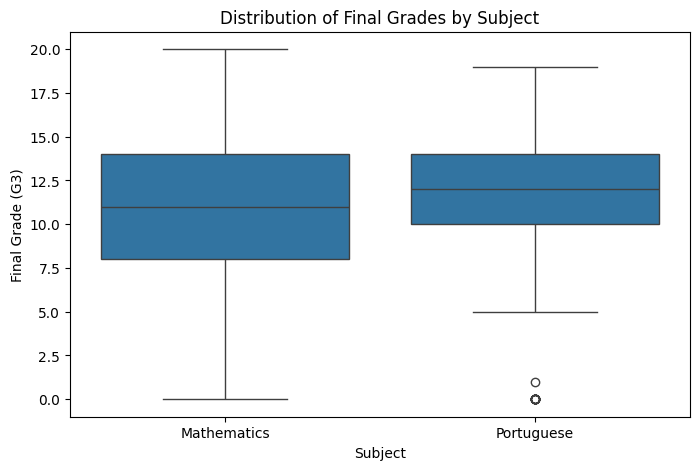

In [10]:
#Visualization 1 — Final Grade Distribution by Subject
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=cleaned_df,
    x="subject",
    y="G3"
)

plt.title("Distribution of Final Grades by Subject")
plt.xlabel("Subject")
plt.ylabel("Final Grade (G3)")

plt.show()

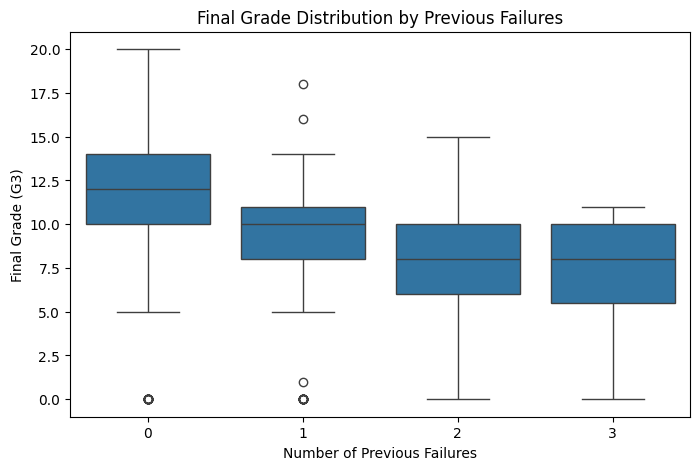

In [11]:
#Visualization 2 — Effect of Previous Failures on Final Grade
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=cleaned_df,
    x="failures",
    y="G3"
)

plt.title("Final Grade Distribution by Previous Failures")
plt.xlabel("Number of Previous Failures")
plt.ylabel("Final Grade (G3)")

plt.show()

  absence_group         G3
0           0-5  11.404402
1          6-10  11.673267
2         11-20  10.347826
3         21-40  10.600000
4           41+   9.333333


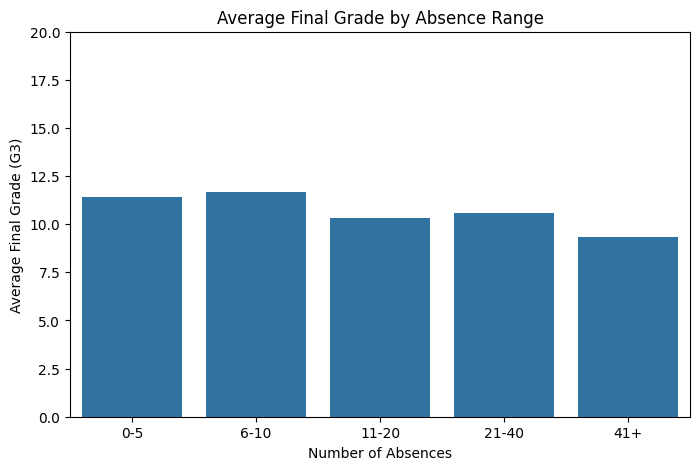

In [13]:
#Visualization 3 — Absences vs Final Grade
# Create absence categories
cleaned_df["absence_group"] = pd.cut(
    cleaned_df["absences"],
    bins=[-1, 5, 10, 20, 40, 100],
    labels=["0-5", "6-10", "11-20", "21-40", "41+"]
)

# Calculate average final grade for each absence group
absence_performance = (
    cleaned_df.groupby("absence_group", observed=False)["G3"]
    .mean()
    .reset_index()
)

print(absence_performance)

# Create the visualization
plt.figure(figsize=(8, 5))

sns.barplot(
    data=absence_performance,
    x="absence_group",
    y="G3"
)

plt.title("Average Final Grade by Absence Range")
plt.xlabel("Number of Absences")
plt.ylabel("Average Final Grade (G3)")

plt.ylim(0, 20)

plt.show()

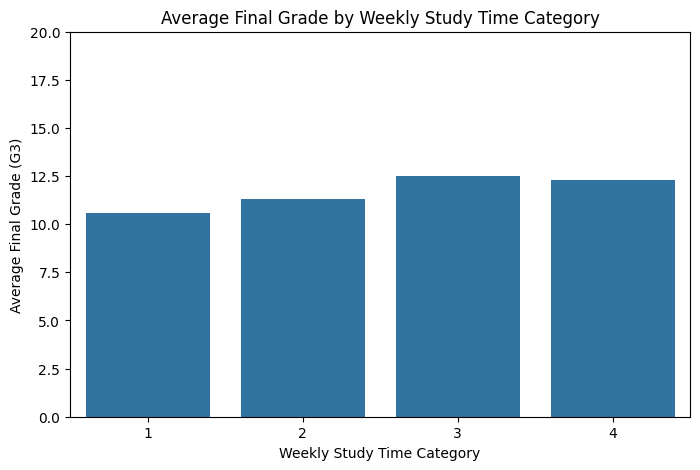

In [14]:
#Visualization 4 — Study Time and Final Grade
plt.figure(figsize=(8, 5))

study_performance = (
    cleaned_df.groupby("studytime", observed=False)["G3"]
    .mean()
    .reset_index()
)

sns.barplot(
    data=study_performance,
    x="studytime",
    y="G3"
)

plt.title("Average Final Grade by Weekly Study Time Category")
plt.xlabel("Weekly Study Time Category")
plt.ylabel("Average Final Grade (G3)")
plt.ylim(0, 20)

plt.show()

In [15]:
#Identify the strongest predictors of final performance
# Correlation of numerical variables with final grade
correlation_with_g3 = (
    cleaned_df.select_dtypes(include="number")
    .corr()["G3"]
    .sort_values(ascending=False)
)

print("Correlation of numerical variables with Final Grade (G3):")
print(correlation_with_g3)

Correlation of numerical variables with Final Grade (G3):
G3            1.000000
G2            0.910743
G1            0.809142
Medu          0.201472
studytime     0.161629
Fedu          0.159796
famrel        0.054461
absences     -0.045671
freetime     -0.064890
health       -0.080079
goout        -0.097877
traveltime   -0.102627
Walc         -0.115740
age          -0.125282
Dalc         -0.129642
failures     -0.383145
Name: G3, dtype: float64


In [19]:
#Analyze important categorical factors
important_categories = ['sex', 'school', 'address', 'higher', 'internet']

for column in important_categories:
    print(f"\nAverage Final Grade by {column}:")
    print(combined_df.groupby(column)['G3'].mean().sort_values(ascending=False))


Average Final Grade by sex:
sex
F    11.448393
M    11.203091
Name: G3, dtype: float64

Average Final Grade by school:
school
GP    11.633420
MS    10.514706
Name: G3, dtype: float64

Average Final Grade by address:
address
U    11.620553
R    10.600000
Name: G3, dtype: float64

Average Final Grade by higher:
higher
yes    11.620942
no      8.348315
Name: G3, dtype: float64

Average Final Grade by internet:
internet
yes    11.553809
no     10.534562
Name: G3, dtype: float64


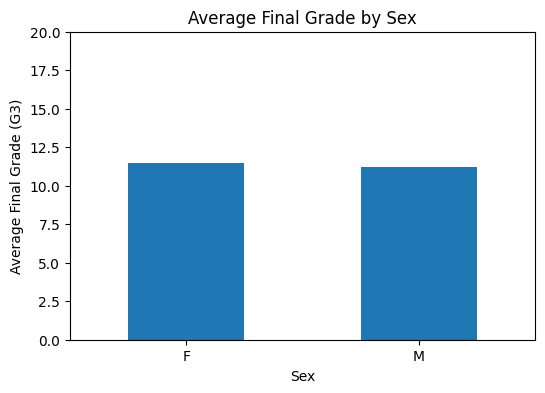

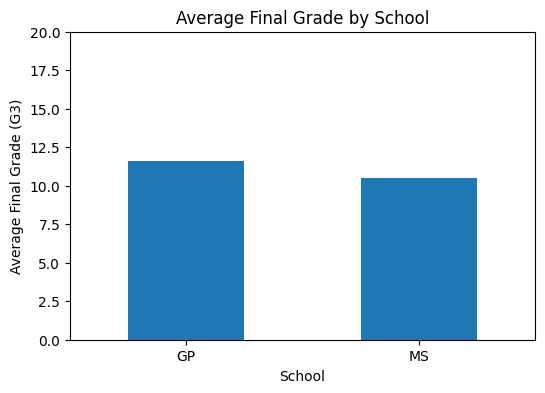

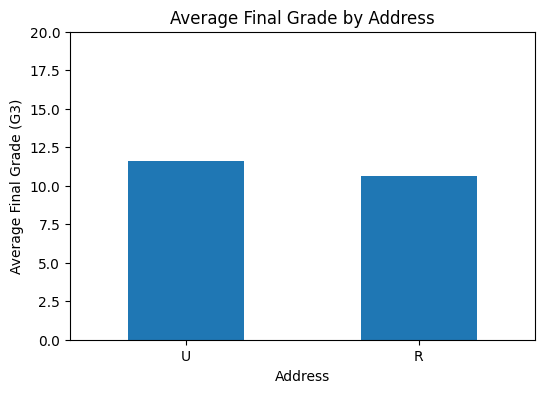

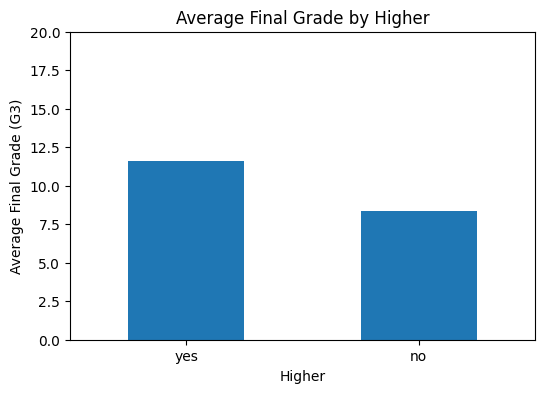

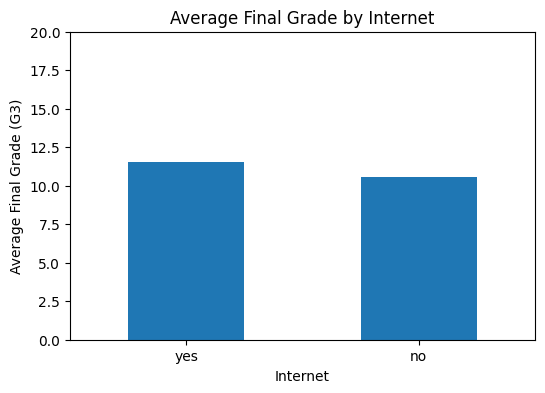

In [20]:
category_columns = ['sex', 'school', 'address', 'higher', 'internet']

for column in category_columns:
    plt.figure(figsize=(6, 4))

    combined_df.groupby(column)['G3'].mean().sort_values(ascending=False).plot(
        kind='bar'
    )

    plt.title(f'Average Final Grade by {column.capitalize()}')
    plt.xlabel(column.capitalize())
    plt.ylabel('Average Final Grade (G3)')
    plt.ylim(0, 20)
    plt.xticks(rotation=0)
    plt.show()

In [21]:
correlation_without_previous_grades = (
    combined_df.select_dtypes(include='number')
    .corr()['G3']
    .drop(['G3', 'G1', 'G2'])
    .sort_values()
)

print("Factors most negatively associated with Final Grade:")
print(correlation_without_previous_grades.head())

print("\nFactors most positively associated with Final Grade:")
print(correlation_without_previous_grades.tail())

Factors most negatively associated with Final Grade:
failures     -0.383145
Dalc         -0.129642
age          -0.125282
Walc         -0.115740
traveltime   -0.102627
Name: G3, dtype: float64

Factors most positively associated with Final Grade:
absences    -0.045671
famrel       0.054461
Fedu         0.159796
studytime    0.161629
Medu         0.201472
Name: G3, dtype: float64


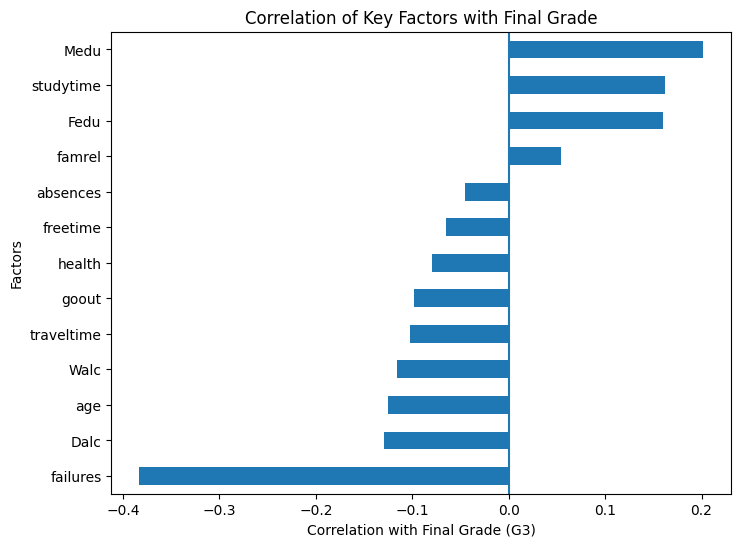

In [22]:
#final correlation visualization
selected_factors = correlation_without_previous_grades.sort_values()

plt.figure(figsize=(8, 6))
selected_factors.plot(kind='barh')

plt.title('Correlation of Key Factors with Final Grade')
plt.xlabel('Correlation with Final Grade (G3)')
plt.ylabel('Factors')
plt.axvline(x=0)
plt.show()

# Key Findings and Strategic Recommendations

## Key Findings

1. **Previous academic failures showed the strongest negative relationship with final grade.** Students with a higher number of previous failures generally achieved lower final grades.

2. **Parental education showed a positive relationship with academic performance.** Mother's education had the strongest positive correlation among the analysed factors, followed by study time and father's education.

3. **Study time was positively associated with final grades.** Students in higher weekly study-time categories generally achieved better average grades.

4. **Students who planned to pursue higher education performed considerably better.** This was one of the strongest differences observed among the categorical variables.

5. **Students from GP school and urban areas had higher average final grades** compared with students from MS school and rural areas.

6. **Internet access was associated with slightly higher academic performance.** Students with internet access had a higher average final grade than students without access.

7. **Higher alcohol consumption showed a negative relationship with final grades.** Both daily and weekend alcohol consumption were negatively correlated with academic performance.

8. **Extremely high absence levels were associated with lower academic performance.** However, the overall correlation between absences and final grade was weak, indicating that the relationship may not be strongly linear.

## Strategic Recommendations

### 1. Early Intervention for Students with Previous Failures
Schools should identify students with previous academic failures at an early stage and provide targeted academic support, mentoring, and additional learning assistance.

### 2. Encourage Consistent Study Habits
Students should be encouraged to maintain regular and effective study routines. Schools can provide study-planning guidance and academic support programmes.

### 3. Strengthen Career Guidance and Higher-Education Awareness
The analysis showed that students who planned to pursue higher education achieved substantially higher average grades. Career counselling and awareness programmes may help improve student motivation and academic goals.

### 4. Monitor Students with Very High Absences
Although overall absences showed a weak correlation with final grades, students with extremely high absence levels had lower average performance. Schools should monitor chronic absenteeism and provide appropriate support.

### 5. Promote Healthy Student Behaviour
Since alcohol consumption showed a negative association with academic performance, schools can conduct awareness programmes promoting healthy lifestyle choices and responsible behaviour.

### 6. Improve Access to Educational Resources
Students without internet access had slightly lower average grades. Improving access to digital learning resources may help reduce educational disadvantages.

### 7. Provide Additional Support for Potentially Disadvantaged Students
Students from rural areas, those with longer travel times, and students facing academic difficulties may benefit from additional academic and institutional support.

## Overall Conclusion

The analysis indicates that academic performance is influenced by multiple factors rather than a single variable. Previous academic failures emerged as the strongest negative factor, while parental education, study time, and higher-education aspirations were associated with better performance. These findings suggest that early academic intervention, consistent study habits, student motivation, access to educational resources, and targeted support can contribute to improved student outcomes.